telegram: @nicktrtu

ноутбук выполнялся на локальном компьютере

датасеты закачивались, потом код закачки комментировался и в последующем датасеты загружались с локальных папок

все задания выполнены, из двух бонусов выполнен первый

# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [1]:
#!pip install kagglehub

In [2]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub
import torch
from tqdm.notebook import tqdm
import itertools

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

**Скачивал один раз, потом работал локально**

In [3]:
# Скачиваем картинки
#images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

images_path = 'datasets/jessicali9530/lfw-dataset/versions/4'
#print("Path to dataset files:", images_path)


In [4]:
# Скачиваем атрибуты
#attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
#print("Path to dataset files:", attrs_path)

attrs_path = 'datasets/averkij/lfw-attributes/versions/1'

In [5]:
#DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
#ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"
DATASET_PATH = images_path + "/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = attrs_path + "/lfw_attributes.txt"


In [6]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values)#.astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)    

    return images, attrs

In [7]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()

**Подготовка картинок к нужному виду**

In [8]:
images = np.array(images, np.float32)
images = images / 255
images = torch.tensor(images).permute(0, 3, 1, 2)
print(images.shape)

torch.Size([13143, 3, 45, 45])



Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [9]:
from sklearn.model_selection import train_test_split
train_photos, val_photos, train_attrs, val_attrs = train_test_split(images, attrs,
                                                                    train_size=0.9, shuffle=False)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=32)

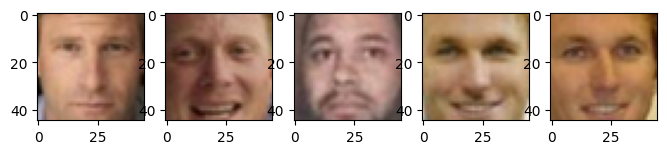

In [10]:
plt.figure(figsize=(8, 20))
for i, image in enumerate(images[:5]):
  plt.subplot(1, 5, i+1)
  plt.imshow(image.permute(1, 2, 0))  

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



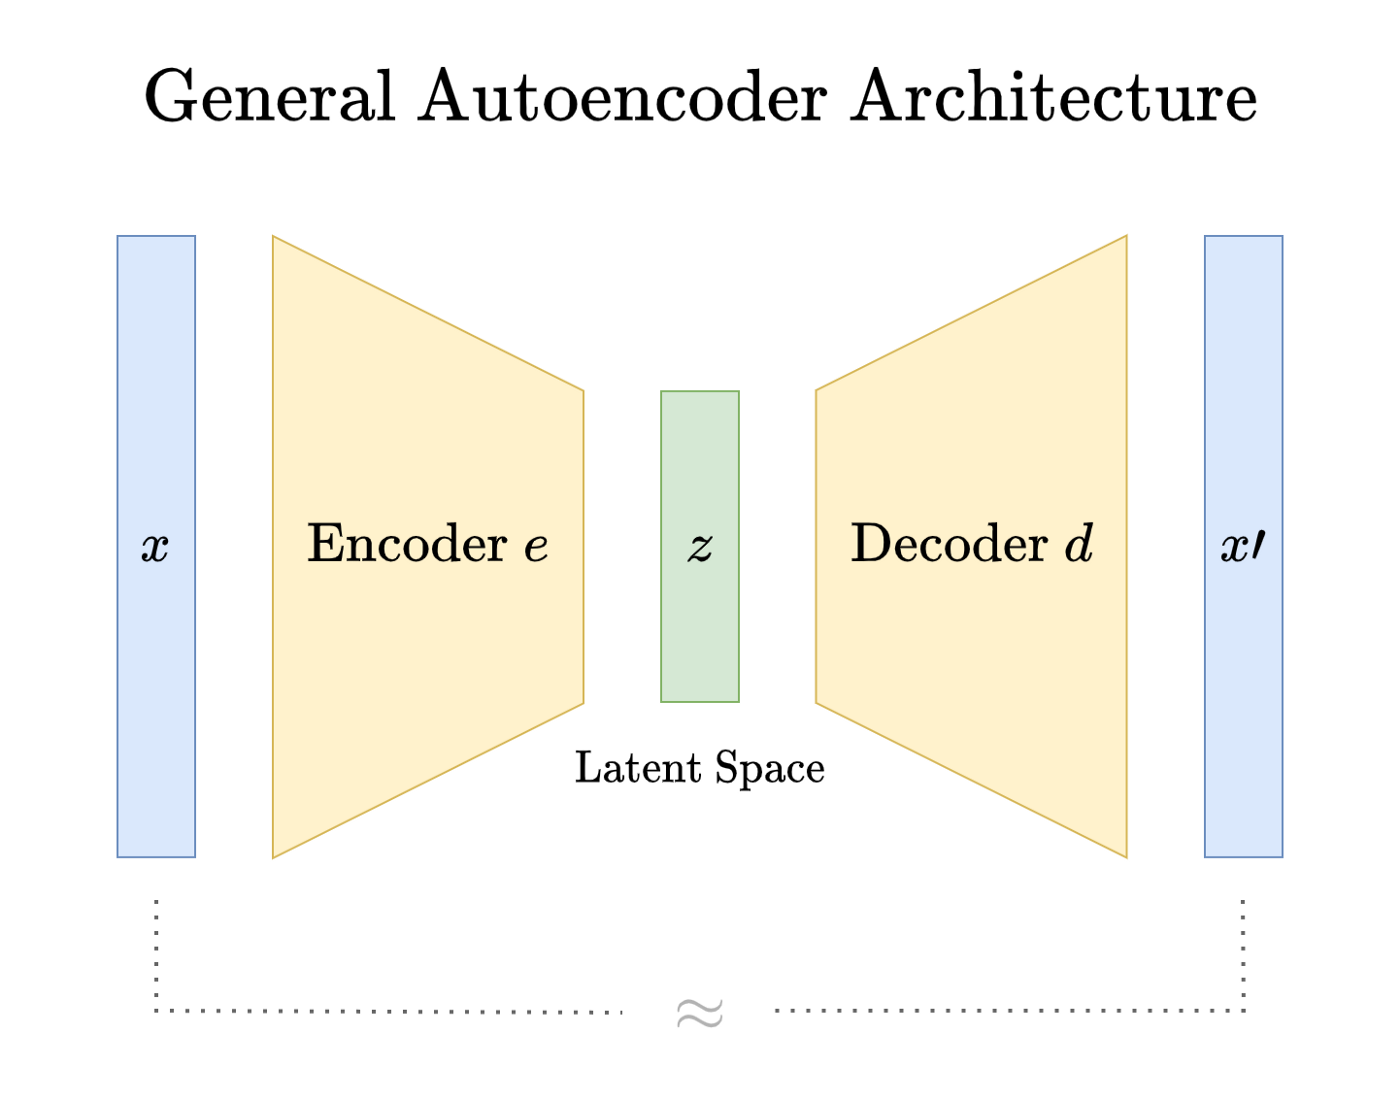

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [11]:
class Encoder(nn.Module):
    def __init__(self, image_size, in_channels, conv_channels, lin_channels, dim_code):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, conv_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(conv_channels),
            nn.ReLU(inplace=True)
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(in_features=image_size[0] * image_size[1] *conv_channels, out_features=lin_channels),
            nn.ReLU(),
            nn.BatchNorm1d(lin_channels),
            nn.Linear(in_features=lin_channels, out_features=dim_code),
            nn.BatchNorm1d(dim_code)
        )
    
    def forward(self, x):
        x = self.conv(x)
        #before_flatten = x.shape
        x = self.flatten(x)
        x = self.fc(x)
        
        #return x, before_flatten
        return x

class Decoder(nn.Module):
    def __init__(self, image_size, in_channels, conv_channels, lin_channels, dim_code):
        super().__init__()
        self.before_flatten = (-1, conv_channels, *image_size)
        self.fc = nn.Sequential(
            nn.Linear(in_features=dim_code, out_features=lin_channels),
            nn.ReLU(),            
            nn.BatchNorm1d(lin_channels),
            nn.Linear(in_features=lin_channels, out_features=image_size[0] * image_size[1]*conv_channels),
            nn.BatchNorm1d(image_size[0] * image_size[1]*conv_channels)
        )
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(conv_channels, conv_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(conv_channels),
            nn.ConvTranspose2d(conv_channels, in_channels, kernel_size=3, padding=1),
        )
    
    #def forward(self, x, before_flatten):
    def forward(self, x):
        x = self.fc(x)
        #print(f'{before_flatten=}')
        x = x.reshape(*self.before_flatten)
        #x = x.reshape(-1, 3, 45, 45)
        
        x = self.conv(x)

        return x


class Autoencoder(nn.Module):
    def __init__(self, image_size, in_channels=3, conv_channels=8, lin_channels=512, dim_code=16):
        super().__init__()
        self.encoder = Encoder(image_size, in_channels=in_channels, conv_channels=conv_channels, lin_channels=lin_channels, dim_code=dim_code)
        self.decoder = Decoder(image_size, in_channels=in_channels, conv_channels=conv_channels, lin_channels=lin_channels, dim_code=dim_code)

    def forward(self, x):
        #latent_code, before_flatten = self.encoder(x)
        latent_code = self.encoder(x)
        #x = self.decoder(latent_code, before_flatten)
        x = self.decoder(latent_code)
        reconstruction = torch.sigmoid(x)
        return reconstruction, latent_code
    
    def sample(self, z):
        generated = self.decoder(z)
        generated = torch.sigmoid(generated)
        #generated = generated.view(-1, 64, 64, 3)
        return generated

In [12]:
'''#test
tmp = Autoencoder(image_size=image_size)
out = tmp(images[0:2])
print(out[0].shape)
print(out[1].shape)

plt.figure(figsize=(8, 4))
plt.imshow(out[0][0].permute(1, 2, 0).detach().numpy())
#''';

In [13]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

In [14]:
dim_code = 1024 # выберите размер латентного вектора
#image_size = images[0].shape[1] * images[0].shape[2]
image_size = images[0].shape[1], images[0].shape[2]
image_size

(45, 45)

In [15]:
criterion = nn.MSELoss()
#criterion = nn.BCELoss()

autoencoder = Autoencoder(image_size=image_size, dim_code=dim_code).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters())

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [16]:
n_epochs = 50
train_losses = []
val_losses = []

for epoch in tqdm(range(n_epochs)):
    autoencoder.train()
    train_losses_per_epoch = []
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstruction, _ = autoencoder(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    train_losses.append(np.mean(train_losses_per_epoch))

    autoencoder.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
        for batch in val_loader:
          batch = batch.to(device)
          reconstruction, _ = autoencoder(batch)
          loss = criterion(reconstruction, batch)
          val_losses_per_epoch.append(loss.item())

    val_losses.append(np.mean(val_losses_per_epoch))

  0%|          | 0/50 [00:00<?, ?it/s]

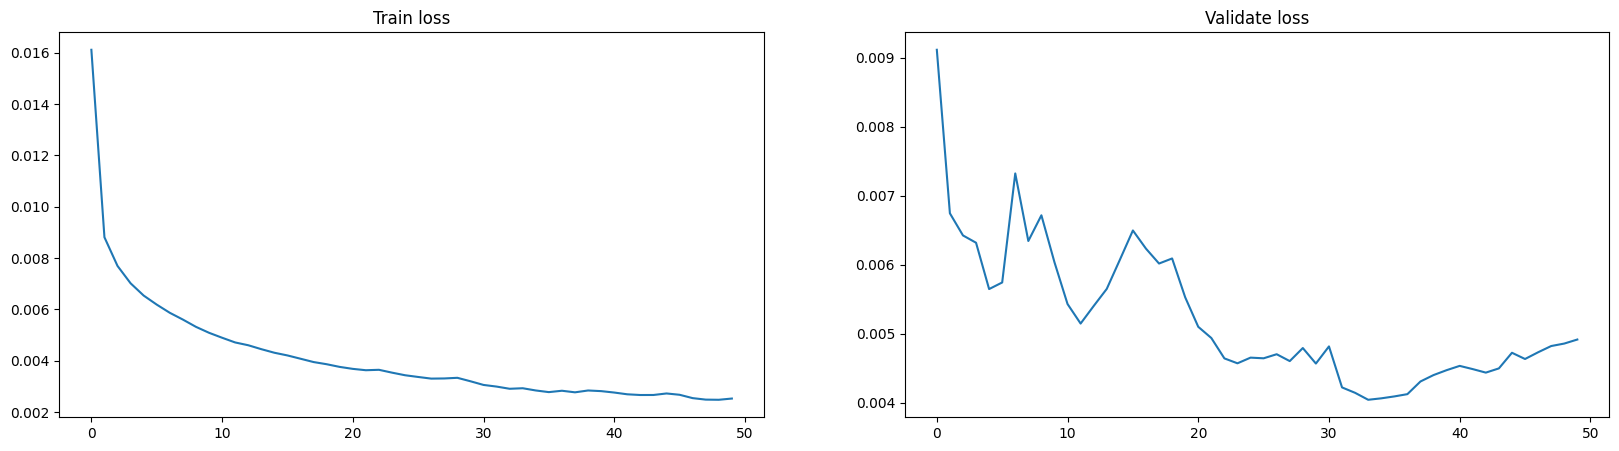

In [17]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title("Train loss")
plt.plot(train_losses)

plt.subplot(1, 2, 2)
plt.title("Validate loss")
plt.plot(val_losses);

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

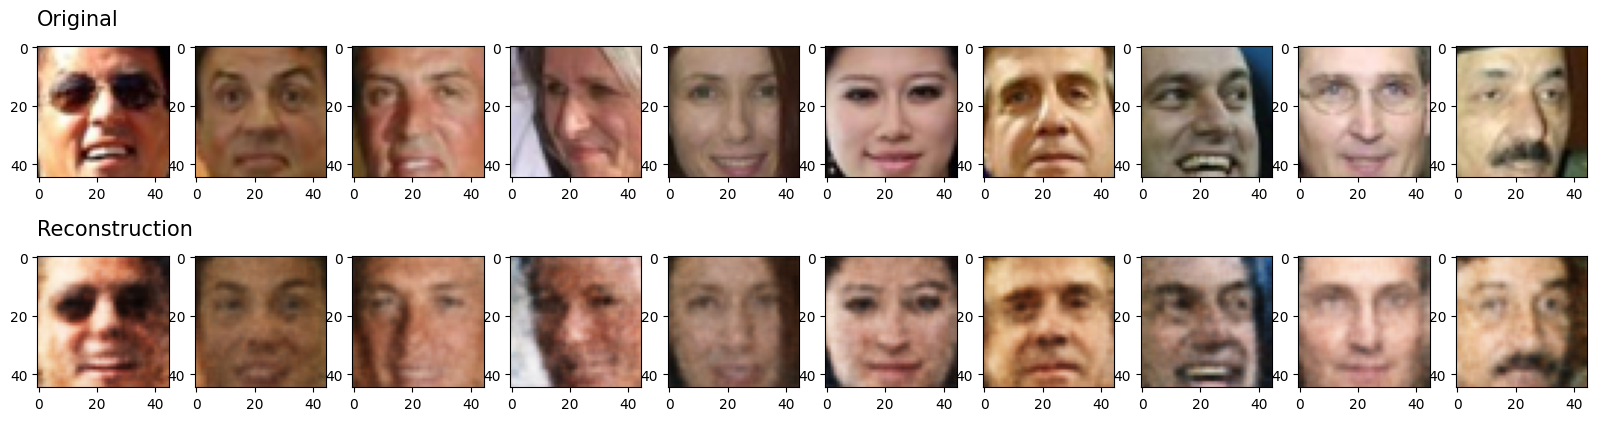

In [18]:
#< тут Ваш код: выведите первые Х картинок и их реконструкций из val выборки на экран>
plt.figure(figsize=(20, 5))
num_draw = 10
img_sample = next(itertools.islice(val_loader, 1))[:num_draw]
result, _ = autoencoder(img_sample.to(device))
for i, image in enumerate(img_sample[:num_draw]):
    plt.subplot(2, num_draw, i + 1)
    if not i:
        plt.title('Original', loc='left', fontsize=15, pad=15)
    plt.imshow(image.permute(1, 2, 0))
    
    plt.subplot(2, num_draw, i + num_draw + 1)
    if not i:
        plt.title('Reconstruction', loc='left', fontsize=15, pad=15)
    plt.imshow(result[i].permute(1, 2, 0).cpu().detach().numpy())


Что вы можете сказать про результат?

**работает, качество так себе**

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [19]:
# сгенерируем 10 рандомных векторов размера latent_space
z = np.random.randn(10, dim_code)
#output = autoencoder.sample(torch(z).to(device))
output = autoencoder.sample(torch.FloatTensor(z).to(device))
output.shape

torch.Size([10, 3, 45, 45])

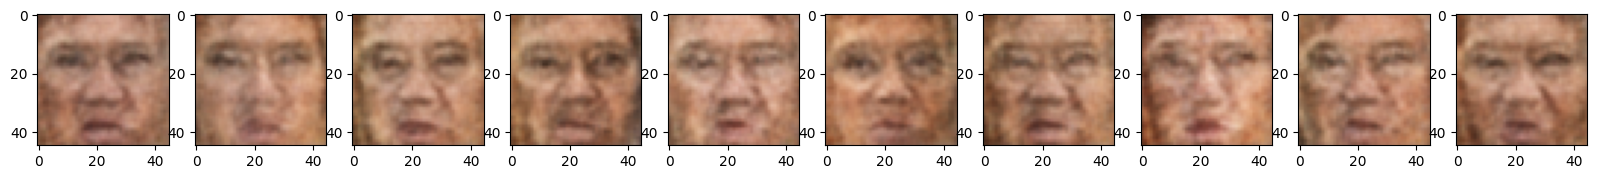

In [20]:
plt.figure(figsize=(20, 5))
for i, image in enumerate(output):
    plt.subplot(1, 10, i + 1)    
    plt.imshow(image.permute(1, 2, 0).cpu().detach().numpy())


## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [21]:
attrs.columns

Index(['Male', 'Asian', 'White', 'Black', 'Baby', 'Child', 'Youth',
       'Middle Aged', 'Senior', 'Black Hair', 'Blond Hair', 'Brown Hair',
       'Bald', 'No Eyewear', 'Eyeglasses', 'Sunglasses', 'Mustache', 'Smiling',
       'Frowning', 'Chubby', 'Blurry', 'Harsh Lighting', 'Flash',
       'Soft Lighting', 'Outdoor', 'Curly Hair', 'Wavy Hair', 'Straight Hair',
       'Receding Hairline', 'Bangs', 'Sideburns', 'Fully Visible Forehead',
       'Partially Visible Forehead', 'Obstructed Forehead', 'Bushy Eyebrows',
       'Arched Eyebrows', 'Narrow Eyes', 'Eyes Open', 'Big Nose',
       'Pointy Nose', 'Big Lips', 'Mouth Closed', 'Mouth Slightly Open',
       'Mouth Wide Open', 'Teeth Not Visible', 'No Beard', 'Goatee',
       'Round Jaw', 'Double Chin', 'Wearing Hat', 'Oval Face', 'Square Face',
       'Round Face', 'Color Photo', 'Posed Photo', 'Attractive Man',
       'Attractive Woman', 'Indian', 'Gray Hair', 'Bags Under Eyes',
       'Heavy Makeup', 'Rosy Cheeks', 'Shiny Skin', 'Pa

In [22]:
attrs[['Smiling', 'Frowning']].sort_values('Smiling', ascending=False)

,Smiling,Frowning
8643,2.839994,-2.767629
1816,2.79183,-2.735255
13034,2.781146,-2.872781
5624,2.743817,-2.860385
1045,2.737038,-2.898542
...,...,...
7065,-2.630769,2.584818
5458,-2.639749,2.71643
7506,-2.643547,2.723023
1234,-2.664484,2.68302


In [23]:
smiling_indexes = attrs['Smiling'].sort_values(ascending=False).index[:15]
frowning_indexes = attrs['Frowning'].sort_values(ascending=False).index[:15]

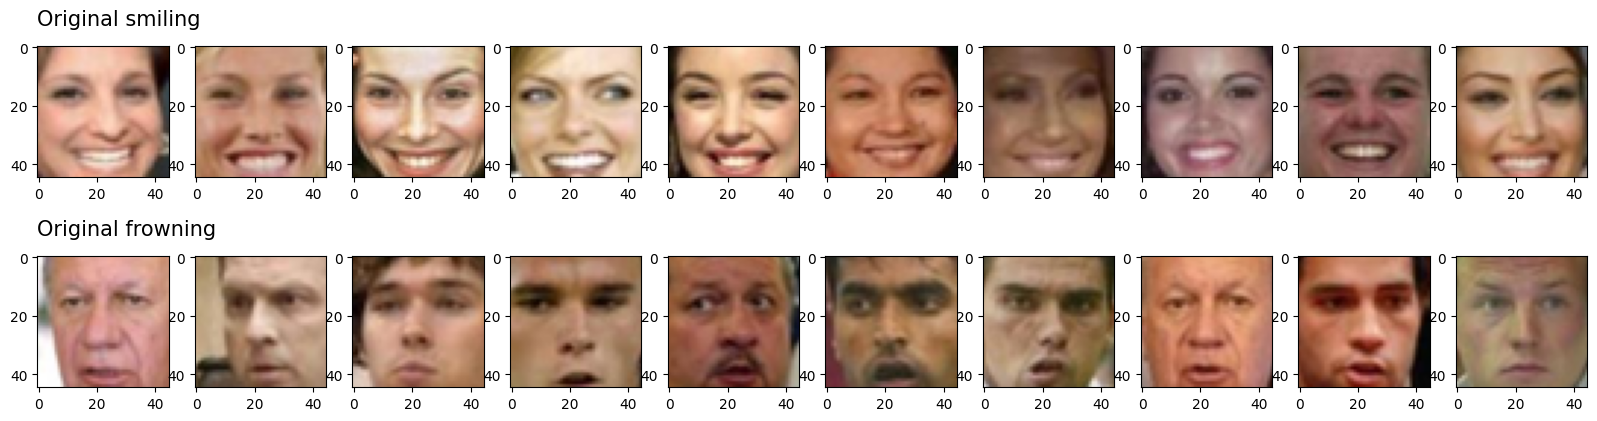

In [24]:
plt.figure(figsize=(20,10))
#num_draw = 10

for i, image in enumerate(images[smiling_indexes[:num_draw]]):
    plt.subplot(1, num_draw, i + 1)
    if not i:
        plt.title('Original smiling', loc='left', fontsize=15, pad=15)
    plt.imshow(image.permute(1, 2, 0))

for i, image in enumerate(images[frowning_indexes[:num_draw]]):
    plt.subplot(2, num_draw, i + 1 + num_draw)
    if not i:
        plt.title('Original frowning', loc='left', fontsize=15, pad=15)
    plt.imshow(image.permute(1, 2, 0))
    
    


In [25]:
_, smiling_vectors = autoencoder(torch.FloatTensor(images[smiling_indexes]).to(device))
_, frowning_vectors = autoencoder(torch.FloatTensor(images[frowning_indexes]).to(device))

smiling_mean = smiling_vectors.mean(axis=0)
frowning_mean = frowning_vectors.mean(axis=0)
dif_vector = smiling_mean - frowning_mean

new_smiling = frowning_vectors + dif_vector

In [26]:
new_smmiling_images = autoencoder.sample(new_smiling)
new_smmiling_images.shape

torch.Size([15, 3, 45, 45])

Вуаля! Вы восхитительны!

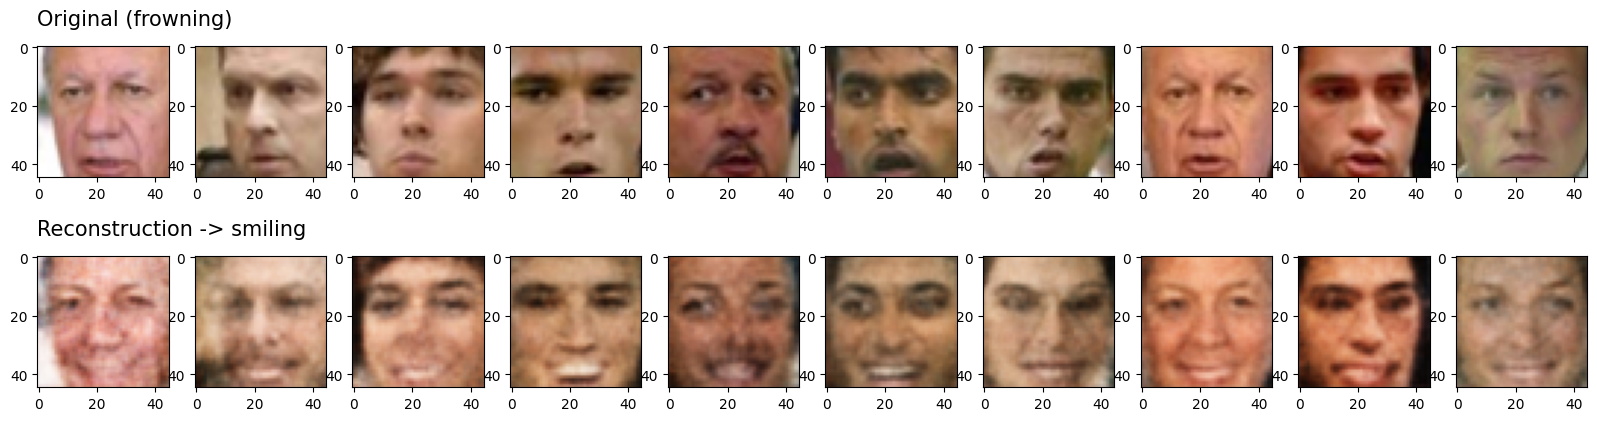

In [27]:
plt.figure(figsize=(20,10))
#num_draw = 10

for i, image in enumerate(images[frowning_indexes[:num_draw]]):
    plt.subplot(1, num_draw, i + 1)
    if not i:
        plt.title('Original (frowning)', loc='left', fontsize=15, pad=15)
    plt.imshow(image.permute(1, 2, 0))

for i, image in enumerate(new_smmiling_images[:num_draw]):
    plt.subplot(2, num_draw, i + 1 + num_draw)
    if not i:
        plt.title('Reconstruction -> smiling', loc='left', fontsize=15, pad=15)
    plt.imshow(image.permute(1, 2, 0).cpu().detach().numpy())
    


Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [28]:
from torchvision import transforms

batch_size = 32
# MNIST Dataset
#train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=False)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [29]:
mist_size = train_dataset.data[0].shape
mist_line_size = train_dataset.data[0].numel()
print(f'{mist_size=}, {mist_line_size=}')

mist_size=torch.Size([28, 28]), mist_line_size=784


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [31]:
class VAE(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()

        self.hidden_dim = hidden_dim

        self.flatten = nn.Flatten()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        self.mean = nn.Linear(64, self.hidden_dim)
        self.log_var = nn.Linear(64, self.hidden_dim)

        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        #encoding
        mean, log_var = self.encode(x)
        z = self.gaussian_sampler(mean, log_var)
        # decoding
        reconstruction = self.decode(z)        
        return reconstruction, mean, log_var
    
    def encode(self, x):
        x = self.flatten(x).float()
        x = self.encoder(x)
        mean = self.mean(x)
        log_var = self.log_var(x)
        return mean, log_var
    
    def decode(self, z):
        reconstruction = self.decoder(z)
        return reconstruction
    
    def gaussian_sampler(self, mean, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var) # standard deviation
            eps = torch.randn_like(std) # `randn_like` as we need the same size
            sample = mean + (eps * std) # sampling as if coming from the input space
            return sample
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mean
        
    def get_latent_vector(self, x):
        mean, log_var = self.encode(x)
        z = self.gaussian_sampler(mean, log_var)        
        return z


Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [32]:
def KL_divergence(mu, logsigma):
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    #loss = -0.5 * torch.mean(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    loss = nn.BCELoss(reduction='sum')
    #loss = nn.BCELoss()
    return loss(reconstruction, x)

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

И обучим модель:

In [33]:
criterion = loss_vae

features = 10
autoencoder = VAE(mist_line_size, mist_line_size, hidden_dim=features).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

In [34]:
n_epochs = 50
train_losses = []
val_losses = []

for epoch in tqdm(range(n_epochs)):
    autoencoder.train()
    train_losses_per_epoch = []
    for x_train, y_train in train_loader:
        x_train = x_train.to(device)
        optimizer.zero_grad()
        reconstruction, mu, logsigma = autoencoder(x_train)
        reconstruction = reconstruction.view(-1, 1, *mist_size)
        loss = criterion(x_train, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    train_losses.append(np.mean(train_losses_per_epoch))

    autoencoder.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
        for x_valid, y_valid in test_loader:
          x_valid = x_valid.to(device)
          reconstruction, mu, logsigma = autoencoder(x_valid)
          reconstruction = reconstruction.view(-1, 1, *mist_size)
          #loss = criterion(batch.to(device).float(), mu, logsigma, reconstruction)
          loss = criterion(x_valid, mu, logsigma, reconstruction)
          val_losses_per_epoch.append(loss.item())

    val_losses.append(np.mean(val_losses_per_epoch))

  0%|          | 0/50 [00:00<?, ?it/s]

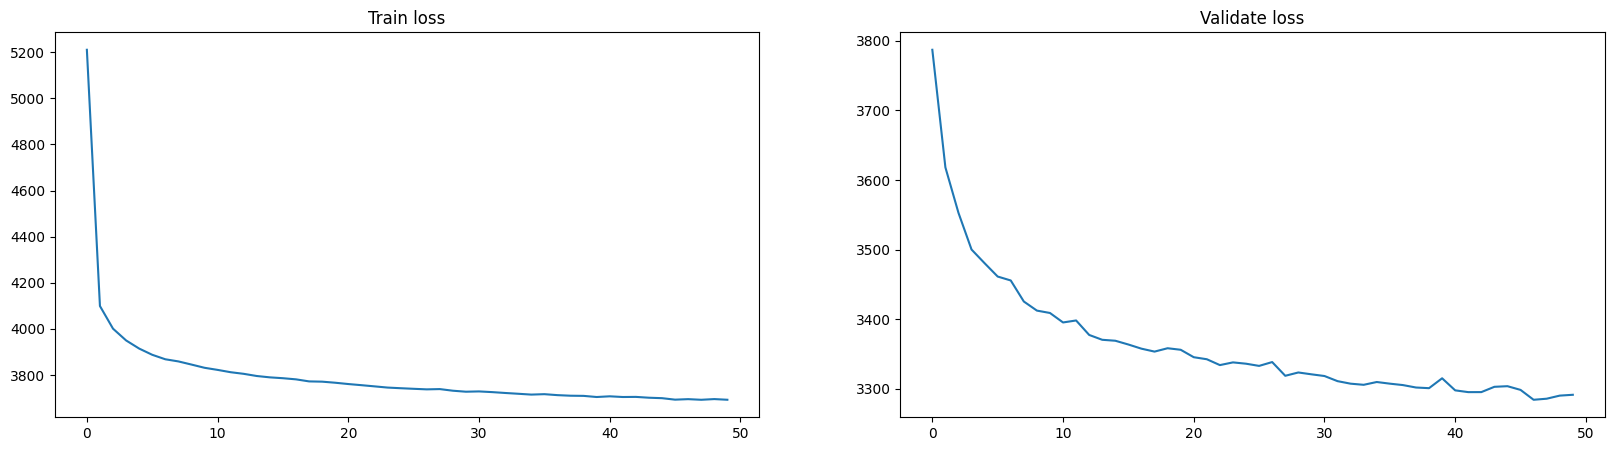

In [35]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title("Train loss")
plt.plot(train_losses)

plt.subplot(1, 2, 2)
plt.title("Validate loss")
plt.plot(val_losses);

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

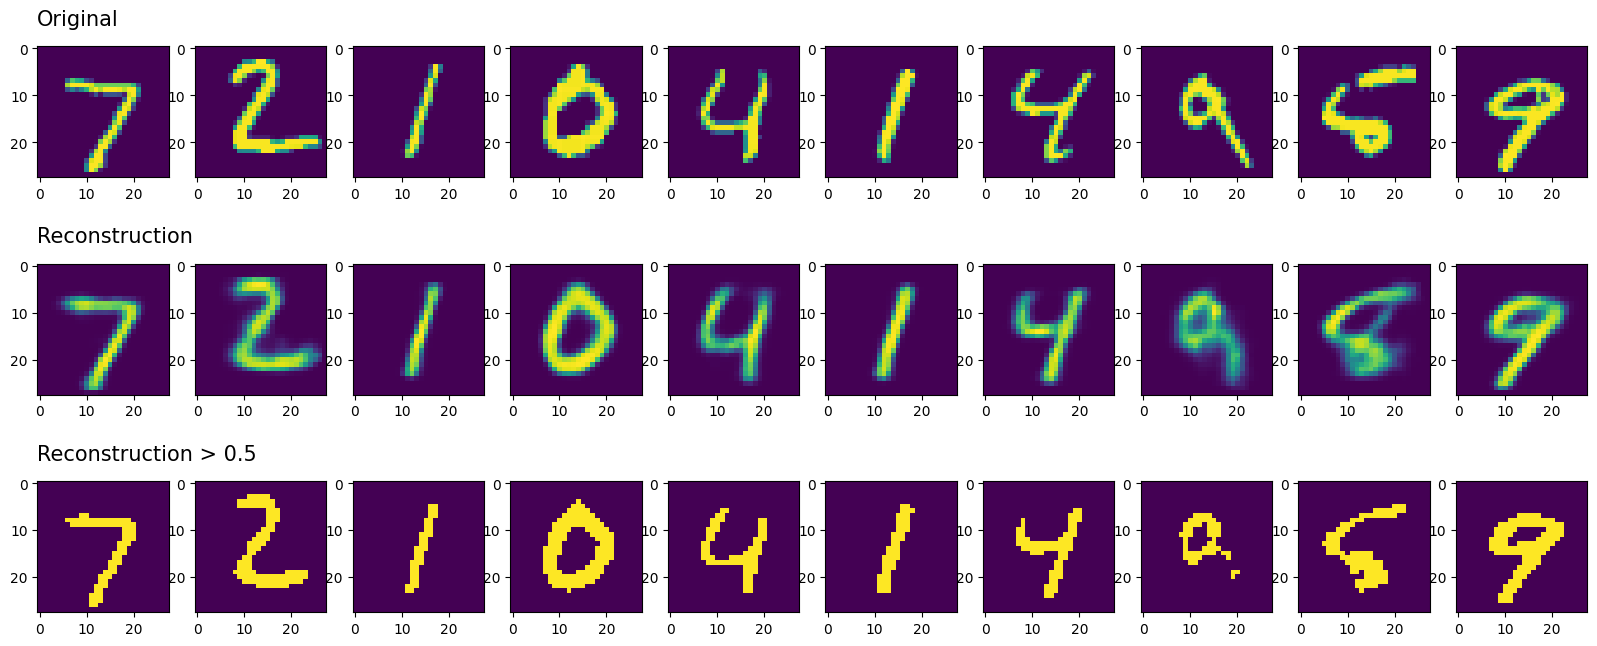

In [36]:
#< тут Ваш код: выведите первые Х картинок и их реконструкций из val выборки на экран>
plt.figure(figsize=(20, 8))
num_draw = 10
x_valid, _ = next(itertools.islice(test_loader, 1))[:num_draw]
#x_valid = x_valid.to(device)
#autoencoder.eval()
res, _, _ = autoencoder(x_valid.to(device))
res_level = res > 0.5

for i, image in enumerate(x_valid[:num_draw]):
    plt.subplot(3, num_draw, i + 1)
    #plt.imshow(image.permute(1, 2, 0))
    if not i:
        plt.title('Original', loc='left', fontsize=15, pad=15)
    plt.imshow(image.view(28, 28))

    plt.subplot(3, num_draw, i + num_draw + 1)
    if not i:
        plt.title('Reconstruction', loc='left', fontsize=15, pad=15)
    plt.imshow(res[i].cpu().detach().squeeze(0).view(28, 28))

    plt.subplot(3, num_draw, i + num_draw *2 + 1)
    if not i:
        plt.title('Reconstruction > 0.5', loc='left', fontsize=15, pad=15)
    plt.imshow(res_level[i].cpu().detach().squeeze(0).view(28, 28))


Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [37]:
z = np.random.randn(num_draw, features)
#output = autoencoder.sample(torch.FloatTensor(z).to(device))
output = autoencoder.decode(torch.FloatTensor(z).to(device))
output.shape

torch.Size([10, 784])

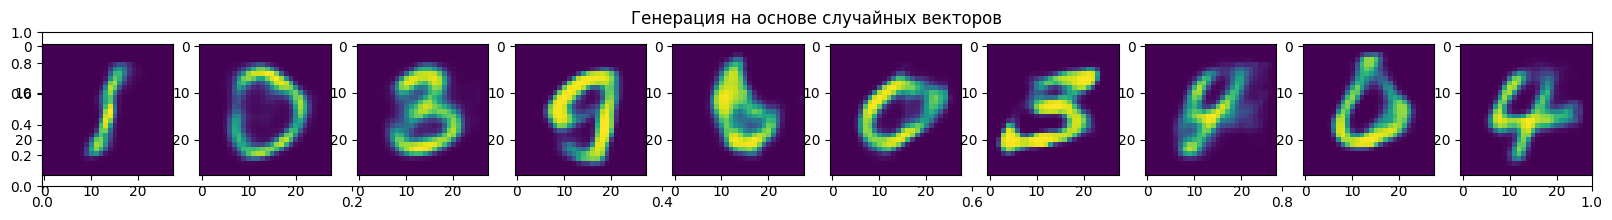

In [43]:
plt.figure(figsize=(20, 2))
plt.title('Генерация на основе случайных векторов')
for i, image in enumerate(output):
    plt.subplot(1, num_draw, i + 1)
    plt.imshow(output[i].cpu().detach().squeeze(0).view(28, 28))

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [44]:
x = test_dataset.data.to(device)
y = test_dataset.targets
x_vectors = autoencoder.get_latent_vector(x)

In [45]:
from sklearn.manifold import TSNE
embed = TSNE(
    n_components=2, # Размерность вложенного пространства.
    perplexity=10, # значение по умолчанию=30.0. Перплексия связана с количеством ближайших соседей, которое используется в других алгоритмах обучения на множествах.
    max_iter=5000,
    random_state=42,
    n_jobs=-1, # значение по умолчанию=None. Количество параллельных заданий для поиска соседей. -1 означает использование всех процессоров.
)
X_embedded = embed.fit_transform(x_vectors.cpu().detach().numpy())

print('New Shape of X: ', X_embedded.shape)
print('Kullback-Leibler divergence after optimization: ', embed.kl_divergence_)
print('No. of iterations: ', embed.n_iter_)

New Shape of X:  (10000, 2)
Kullback-Leibler divergence after optimization:  1.8342841863632202
No. of iterations:  4999


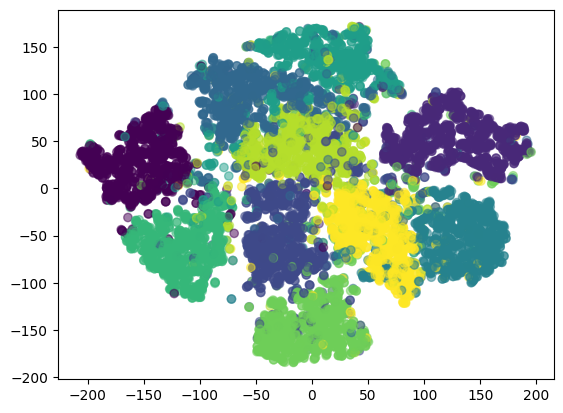

In [46]:
plt.scatter(x=X_embedded[:,0], y=X_embedded[:,1], alpha=0.5, c=y);

Что вы думаете о виде латентного представления?

**Каждой цифре соответствует своя область.**


__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [47]:
class CVAE(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()

        self.hidden_dim = hidden_dim

        self.flatten = nn.Flatten()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim+10, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        self.mean = nn.Linear(64, self.hidden_dim)
        self.log_var = nn.Linear(64, self.hidden_dim)

        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim + 10, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x, class_num):
        #encoding
        #class_num = F.one_hot(class_num, num_classes=10)
        mean, log_var, class_num = self.encode(x, class_num)
        z = self.gaussian_sampler(mean, log_var)
        # decoding
        #reconstruction = self.decode(z, class_num)
        z = torch.cat((class_num, z), -1)
        reconstruction = self.decoder(z)
        return reconstruction, mean, log_var
    
    def encode(self, x, class_num):
        x = self.flatten(x).float()
        class_num = F.one_hot(class_num, num_classes=10)
        #print(f'{x.shape=}, {class_num.shape=}')
        #x = torch.cat((class_num[:, None], x), -1)
        x = torch.cat((class_num, x), -1)
        x = self.encoder(x)
        mean = self.mean(x)
        log_var = self.log_var(x)
        return mean, log_var, class_num
    
    def decode(self, z, class_num):
        #z = torch.cat((class_num[:, None], z), -1)
        class_num = F.one_hot(class_num, num_classes=10)
        z = torch.cat((class_num, z), -1)
        reconstruction = self.decoder(z)
        return reconstruction
    
    def gaussian_sampler(self, mean, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var) # standard deviation
            eps = torch.randn_like(std) # `randn_like` as we need the same size
            sample = mean + (eps * std) # sampling as if coming from the input space
            return sample
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mean
        
    def get_latent_vector(self, x, class_num):
        mean, log_var, class_num = self.encode(x, class_num)
        z = self.gaussian_sampler(mean, log_var)
        z = torch.cat((class_num, z), -1)
        return z

In [48]:
criterion = loss_vae

features = 10
autoencoder = CVAE(mist_line_size, mist_line_size, hidden_dim=features).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters())

In [49]:
n_epochs = 50
train_losses = []
val_losses = []

for epoch in tqdm(range(n_epochs)):
    autoencoder.train()
    train_losses_per_epoch = []
    for x_train, y_train in train_loader:        
        x_train = x_train.to(device)        
        #y_train = F.one_hot(y_train.to(device), num_classes=10)
        y_train = y_train.to(device)
        optimizer.zero_grad()
        reconstruction, mu, logsigma = autoencoder(x_train, y_train)
        reconstruction = reconstruction.view(-1, 1, *mist_size)
        loss = criterion(x_train, mu, logsigma, reconstruction)
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    train_losses.append(np.mean(train_losses_per_epoch))

    autoencoder.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
        for x_valid, y_valid in test_loader:
          x_valid = x_valid.to(device)
          y_valid = y_valid.to(device)
          #y_valid = F.one_hot(y_valid.to(device), num_classes=10)
          reconstruction, mu, logsigma = autoencoder(x_valid, y_valid)
          reconstruction = reconstruction.view(-1, 1, *mist_size)
          #loss = criterion(batch.to(device).float(), mu, logsigma, reconstruction)
          loss = criterion(x_valid, mu, logsigma, reconstruction)
          val_losses_per_epoch.append(loss.item())

    val_losses.append(np.mean(val_losses_per_epoch))

  0%|          | 0/50 [00:00<?, ?it/s]

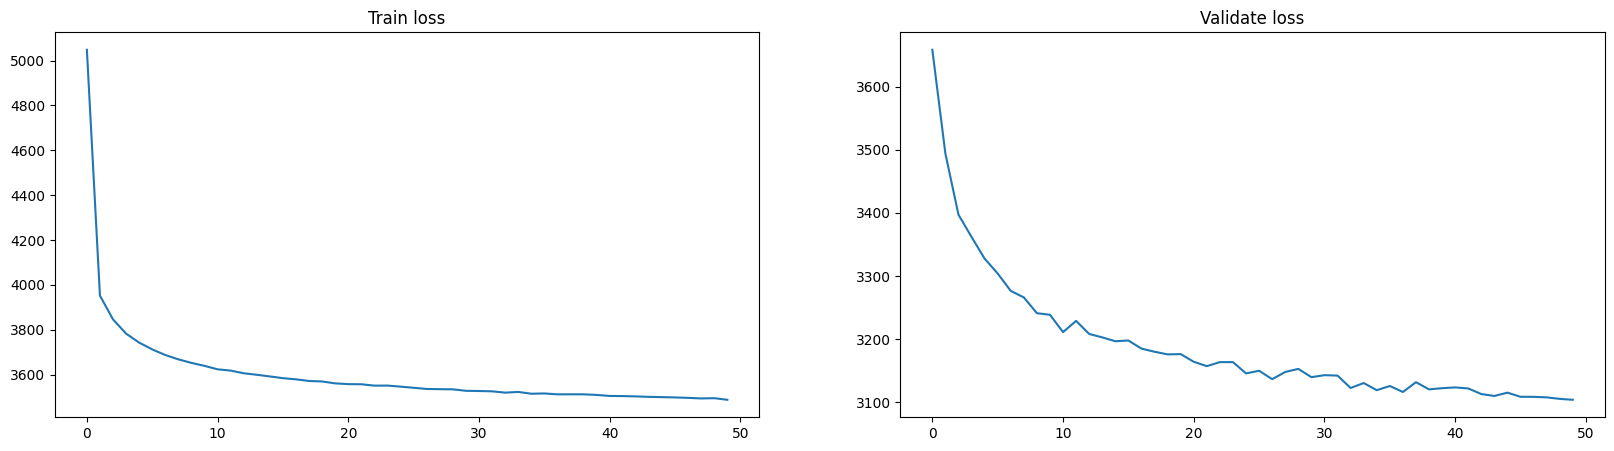

In [50]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title("Train loss")
plt.plot(train_losses)

plt.subplot(1, 2, 2)
plt.title("Validate loss")
plt.plot(val_losses);

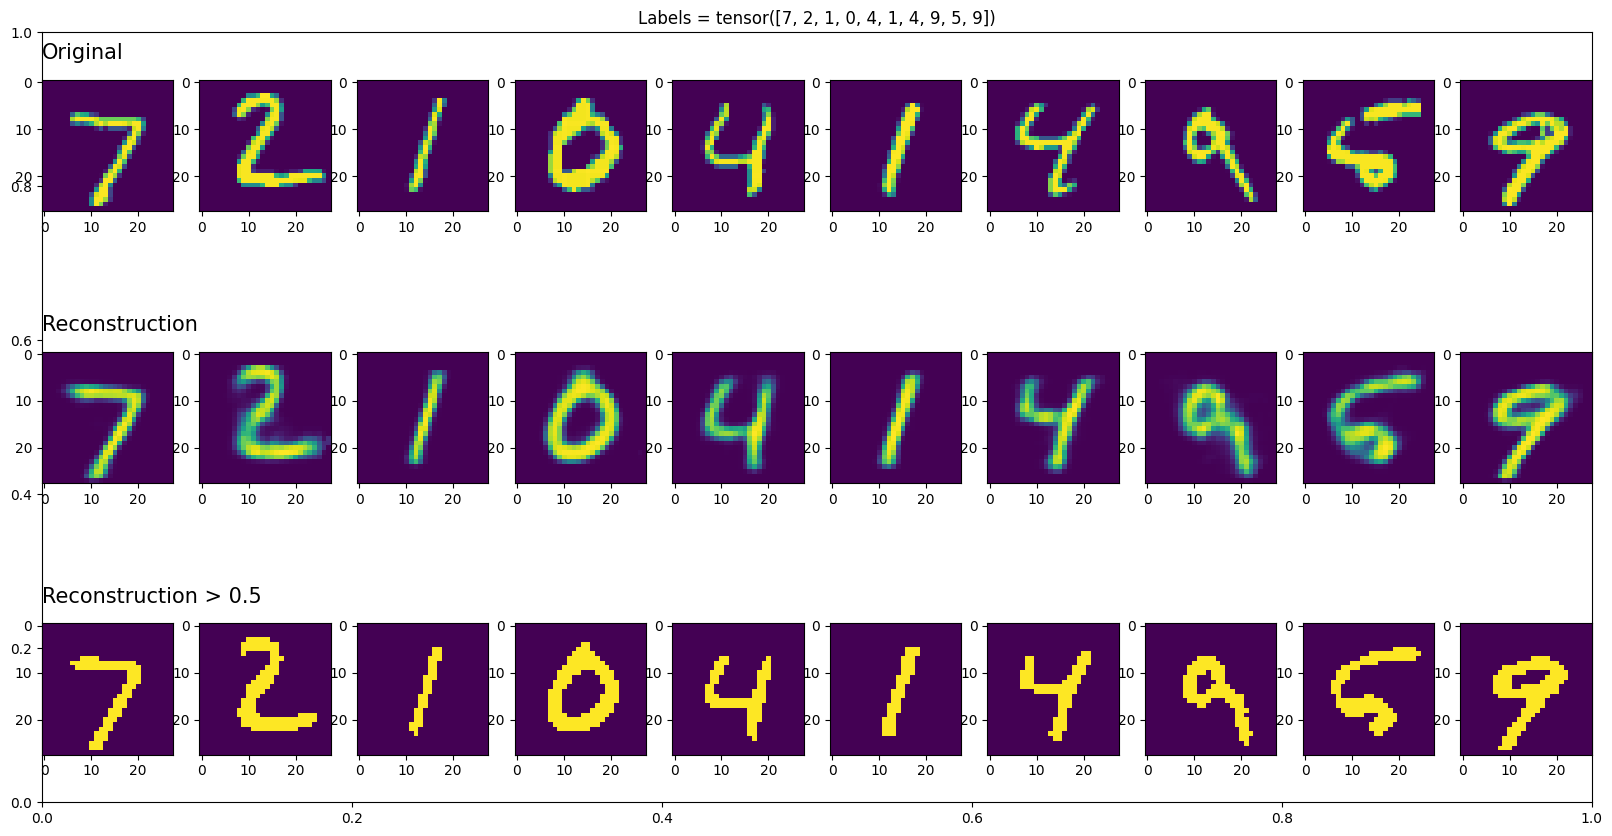

In [54]:
plt.figure(figsize=(20, 10))
num_draw = 10
x_valid, y_valid = next(itertools.islice(test_loader, 1))[:num_draw]
plt.title(f'Labels = {y_valid[:num_draw]}')
#print(f'Labels = {y_valid[:num_draw]}')
#y_valid = F.one_hot(y_valid.to(device), num_classes=10)
res, _, _ = autoencoder(x_valid.to(device), y_valid.to(device))
res_level = res > 0.5

for i, image in enumerate(x_valid[:num_draw]):
    plt.subplot(3, num_draw, i + 1)
    #plt.imshow(image.permute(1, 2, 0))
    if not i:
        plt.title('Original', loc='left', fontsize=15, pad=15)
    plt.imshow(image.view(28, 28))

    plt.subplot(3, num_draw, i + num_draw + 1)
    if not i:
        plt.title('Reconstruction', loc='left', fontsize=15, pad=15)
    plt.imshow(res[i].cpu().detach().squeeze(0).view(28, 28))

    plt.subplot(3, num_draw, i + num_draw *2 + 1)
    if not i:
        plt.title('Reconstruction > 0.5', loc='left', fontsize=15, pad=15)
    plt.imshow(res_level[i].cpu().detach().squeeze(0).view(28, 28))


### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

**10 латентных векторов z, фиксируем для последующих семплирований**

In [55]:
z = np.random.randn(num_draw, features)
z = torch.FloatTensor(z).to(device)

**Семплируем из z цифры от 0 до 9**

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], device='cuda:0')


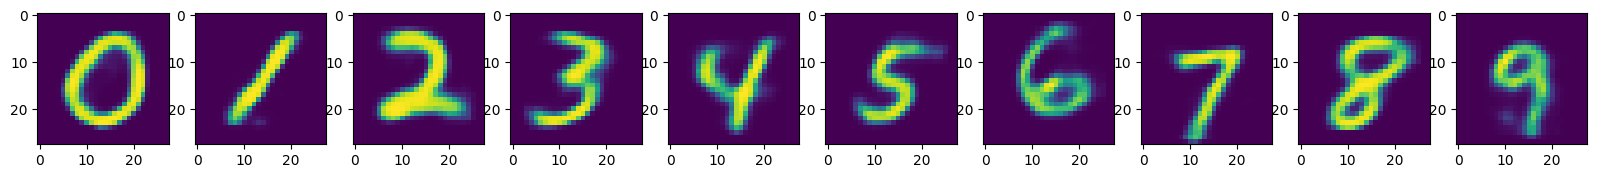

In [56]:
y = torch.LongTensor(range(10)).to(device)
print(y)
#y_valid = F.one_hot(y.to(device), num_classes=10)
output = autoencoder.decode(z, y)
plt.figure(figsize=(20, 8))
for i, image in enumerate(output):
    plt.subplot(1, num_draw, i + 1)
    plt.imshow(output[i].cpu().detach().squeeze(0).view(28, 28))

**Семплируем пятерки**

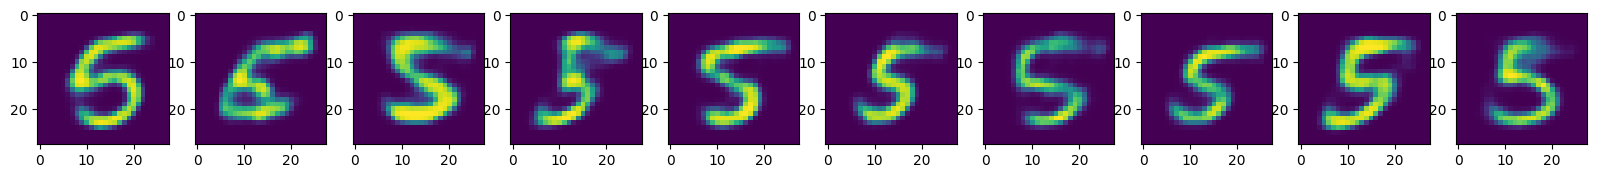

In [57]:
y = torch.LongTensor([5]*10).to(device)
output = autoencoder.decode(z, y)
plt.figure(figsize=(20, 8))
for i, image in enumerate(output):
    plt.subplot(1, num_draw, i + 1)
    plt.imshow(output[i].cpu().detach().squeeze(0).view(28, 28))

**Семплируем семерки**

tensor([7, 7, 7, 7, 7, 7, 7, 7, 7, 7], device='cuda:0')


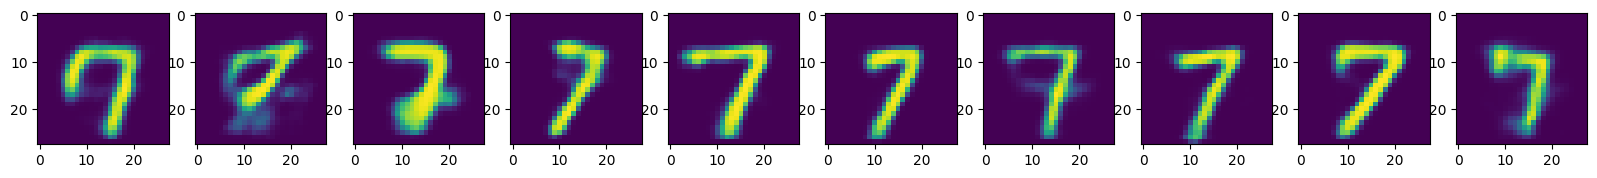

In [58]:
y = torch.LongTensor([7]*10).to(device)
print(y)
output = autoencoder.decode(z, y)
plt.figure(figsize=(20, 8))
for i, image in enumerate(output):
    plt.subplot(1, num_draw, i + 1)
    plt.imshow(output[i].cpu().detach().squeeze(0).view(28, 28))

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [59]:
x = test_dataset.data.to(device)
y = test_dataset.targets

x_vectors = autoencoder.get_latent_vector(x, y.to(device))

In [60]:
embed = TSNE(
    n_components=2, # Размерность вложенного пространства.
    perplexity=10, # значение по умолчанию=30.0. Перплексия связана с количеством ближайших соседей, которое используется в других алгоритмах обучения на множествах.
    max_iter=5000,
    random_state=42,
    n_jobs=-1, # значение по умолчанию=None. Количество параллельных заданий для поиска соседей. -1 означает использование всех процессоров.
)
X_embedded = embed.fit_transform(x_vectors.cpu().detach().numpy())

print('New Shape of X: ', X_embedded.shape)
print('Kullback-Leibler divergence after optimization: ', embed.kl_divergence_)
print('No. of iterations: ', embed.n_iter_)

New Shape of X:  (10000, 2)
Kullback-Leibler divergence after optimization:  1.9431142807006836
No. of iterations:  4999


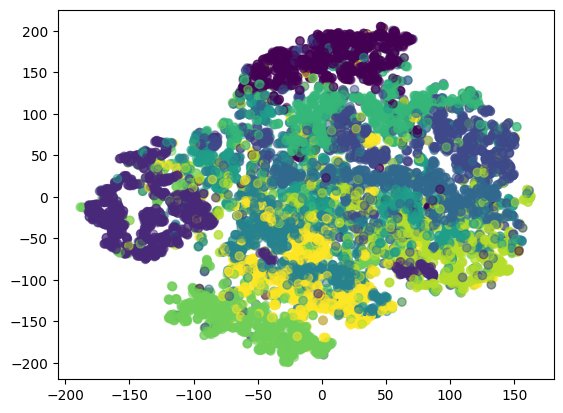

In [61]:
plt.scatter(x=X_embedded[:,0], y=X_embedded[:,1], alpha=0.5, c=y);

**Разделение классов менее выражено. Но размерность латентного пространства увеличилась с 10 до 20 (после OneHot). И соответственно двумерное отображение имеет еще меньше смысла. В 20-мерном пространстве разделение скорее всего хорошее**

# BONUS 1: Denoising (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [62]:
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=32)

In [63]:
noise_factor = 0.3
train_photos_noisy = train_photos + noise_factor * np.random.normal(loc=0.0, scale=0.5, size=train_photos.shape)
val_photos_noisy = val_photos + noise_factor * np.random.normal(loc=0.0, scale=0.5, size=val_photos.shape)
train_photos_noisy = train_photos_noisy.float()
val_photos_noisy = val_photos_noisy.float()
train_noisy_loader = torch.utils.data.DataLoader(train_photos_noisy, batch_size=32)
val_noisy_loader = torch.utils.data.DataLoader(val_photos_noisy, batch_size=32)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.41064832..1.5062559].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3437721..1.1567403].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35860482..1.2680125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27857003..1.3401045].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38406554..1.1782843].


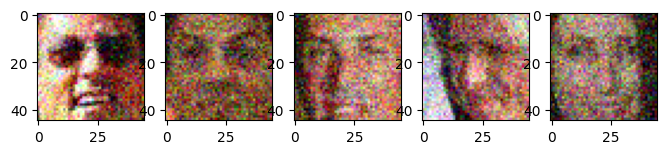

In [64]:
plt.figure(figsize=(8, 20))
for i, image in enumerate(val_photos_noisy[:5]):
  plt.subplot(1, 5, i+1)
  plt.imshow(image.permute(1, 2, 0))  

In [65]:
criterion = nn.MSELoss()
#criterion = nn.BCELoss()

autoencoder = Autoencoder(image_size=image_size, dim_code=dim_code).to(device)

optimizer = torch.optim.Adam(autoencoder.parameters())

In [66]:
n_epochs = 30
train_losses = []
val_losses = []

for epoch in tqdm(range(n_epochs)):
    autoencoder.train()
    train_losses_per_epoch = []
    for batch, batch_noise in zip(train_loader, train_noisy_loader):
    #for batch in train_loader:
        batch = batch.to(device)
        batch_noise = batch_noise.to(device)
        optimizer.zero_grad()
        reconstruction, _ = autoencoder(batch_noise)
        #reconstruction = reconstruction.view(-1, 64, 64, 3)
        #loss = criterion(batch.to(device).float(), mu, logsigma, reconstruction)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        train_losses_per_epoch.append(loss.item())

    train_losses.append(np.mean(train_losses_per_epoch))

    autoencoder.eval()
    val_losses_per_epoch = []
    with torch.no_grad():
        #for batch in val_loader:
        for batch, batch_noise in zip(val_loader, val_noisy_loader):
          batch = batch.to(device)
          batch_noise = batch_noise.to(device)
          reconstruction, _ = autoencoder(batch_noise)
          #reconstruction = reconstruction.view(-1, 64, 64, 3)
          loss = criterion(reconstruction, batch)
          val_losses_per_epoch.append(loss.item())

    val_losses.append(np.mean(val_losses_per_epoch))

  0%|          | 0/30 [00:00<?, ?it/s]

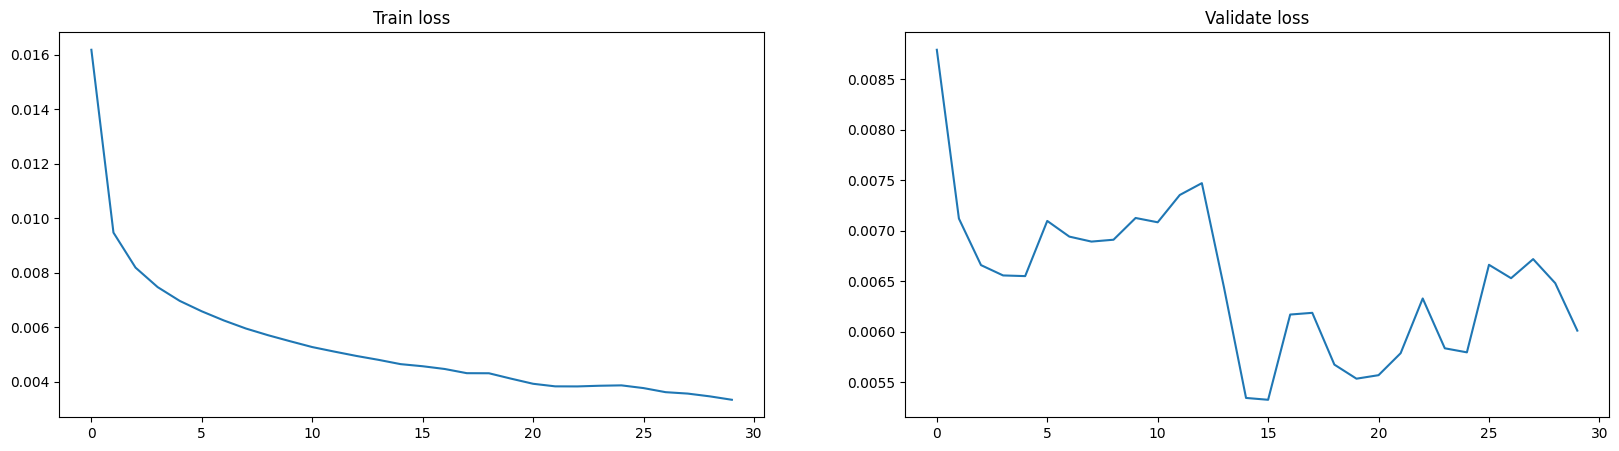

In [67]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.title("Train loss")
plt.plot(train_losses)

plt.subplot(1, 2, 2)
plt.title("Validate loss")
plt.plot(val_losses);

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.41064832..1.5062559].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3437721..1.1567403].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.35860482..1.2680125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27857003..1.3401045].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38406554..1.1782843].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.39424577..1.2687005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4

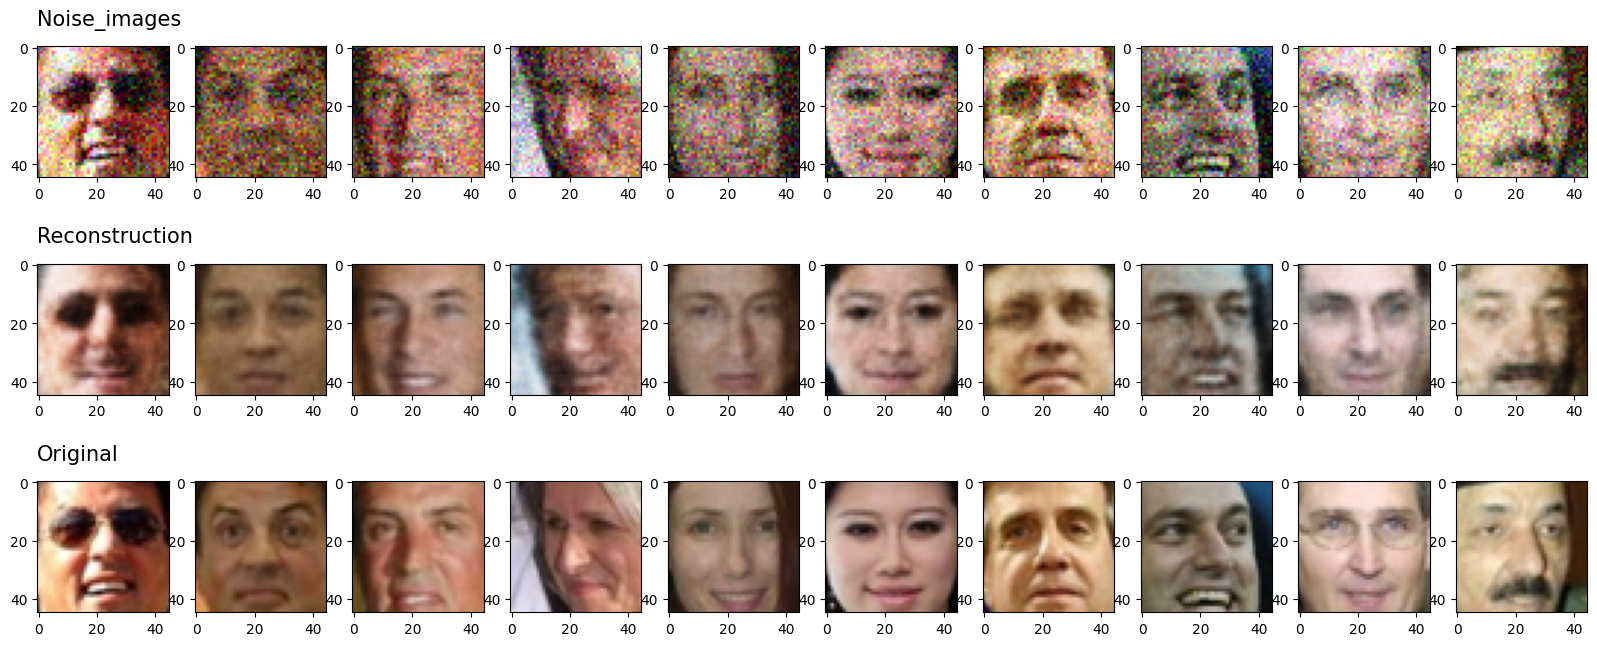

In [68]:
#< тут Ваш код: выведите первые Х картинок и их реконструкций из val выборки на экран>
plt.figure(figsize=(20, 8))
num_draw = 10
img_sample = next(itertools.islice(val_loader, 1))[:num_draw]
img_noise_sample = next(itertools.islice(val_noisy_loader, 1))
result, _ = autoencoder(img_noise_sample.to(device))
for i, image in enumerate(img_noise_sample[:num_draw]):
    plt.subplot(3, num_draw, i + 1)
    if not i:
        plt.title('Noise_images', loc='left', fontsize=15, pad=15)
    plt.imshow(image.permute(1, 2, 0))
    
    plt.subplot(3, num_draw, i + num_draw + 1)
    if not i:
        plt.title('Reconstruction', loc='left', fontsize=15, pad=15)
    plt.imshow(result[i].permute(1, 2, 0).cpu().detach().numpy())

    plt.subplot(3, num_draw, i + num_draw * 2 + 1)
    if not i:
        plt.title('Original', loc='left', fontsize=15, pad=15)
    plt.imshow(img_sample[i].permute(1, 2, 0).cpu().detach().numpy());


# BONUS 2: Image Retrieval (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>